In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quant_rotor.Hamiltonian_models.Dense.hamiltonian import hamiltonian_dense as ham
from quant_rotor.Hamiltonian_models.Dense.heisenberg_operators import heisenberg_operators
from quant_rotor.Hamiltonian_models.Dense.rotor_operators import rotor_operators

from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal import integration_scheme
import quant_rotor.CCC_integration_methods.Dense.thermofield_boltz_funcs as bz

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_guess import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy, intermediate_normalisation

from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import U as U_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import Z as Z_stat

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_sub_class import (
    QuantumSimulation,
    SimulationParams,
    TensorData,
)

In [2]:
np.set_printoptions(precision=10)
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(threshold=np.inf)

# One electron TF

In [ ]:
state = 3
state_2 = state**2
site = 3

p = state
i = 1
a = p - i

g = 0.1
periodic = False

beta = 5

In [ ]:
K, V = rotor_operators(state, g)
H = ham(site, K, V, V, periodic)

In [ ]:
eig_val, eig_vec = np.linalg.eigh(H)

In [ ]:
u_vec = np.exp((-np.diag(K) * beta) / 2)

In [ ]:
physical_hilbert_dim = state

In [ ]:
diagonal_vecs = []

for n in range(physical_hilbert_dim):
    print(-(1 / np.sqrt(physical_hilbert_dim)) * np.copy(u_vec))
    diagonal_vec = -(1/np.sqrt(physical_hilbert_dim))*np.copy(u_vec)
    diagonal_vec[n] +=  1
    diagonal_vecs.append(diagonal_vec)

diagonal_vecs = np.array(diagonal_vecs)

# The diagonal basis is now over-complete we need to use a lowdin procedure
overlap_matrix = diagonal_vecs.T@diagonal_vecs
eig_vals_lowdin,eig_vecs_lowdin = np.linalg.eigh(overlap_matrix)

# Check for eigenvalues that are zero they are linear dependent and can be removed
# this hardcoded because the there should only be 1 excess basis vector and all other eigenvalues will be 1
linearly_independent_eigvals = eig_vals_lowdin[1:]
print(linearly_independent_eigvals)

# Remove linear dependent vector from set of eigenvectors
# Columns of eigh output are the eigenvectors
linearly_independent_vecs = eig_vecs_lowdin[:,1:]

# Find the reduced basis set
# Note: columns are basis vectors
# Reduced basis written C_{m\lambda}
reduced_basis = diagonal_vecs@linearly_independent_vecs

# Create diagonal state basis including
# Diagonal basis as C_{m\lambda}
diagonal_basis = np.zeros((physical_hilbert_dim, physical_hilbert_dim))
diagonal_basis[:,0] = u_vec
diagonal_basis[:,1:] = reduced_basis

In [ ]:
U, _, U_vec = bz.thermofield_change_of_basis_new(K, beta)

# U, Q= bz.thermofield_change_of_basis(K)

I = np.eye(state)

K_prim = np.zeros((state_2, state_2), dtype=complex)

# for i in range(1, state):
#     K_prim[state * i + i, state * i + i] = 1

K_prim = np.einsum('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

K_tilda = U.T @ K_prim @ U

V_tensor = V.reshape(state, state, state, state)

V_prim = np.einsum('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

V_grouped = V_prim.reshape(state**2, state**2, state**2, state**2)

V_tilda = np.einsum('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

In [ ]:
eig_val, eig_vec = np.linalg.eigh(K_tilda)

In [ ]:
V_vec = np.exp((np.diag(K) * beta) / 2)

In [ ]:
p = state_2
i = 1
a = p - i

In [ ]:
V_m = np.zeros((state_2), dtype=complex)

In [ ]:
for x in range(state):
    V_m[x * state + x] += V_vec[x]

In [ ]:
V_p = V_m @ U

In [ ]:
eig_val

In [ ]:
V_p / V_p[0]

In [ ]:
K_tilda @ (V_p)

In [ ]:
(K_tilda @ V_p / V_p[0]) * 3

In [ ]:
t_a_i_tensor = np.zeros((2, a, i), dtype=complex)
t_ab_ij_tensor = np.zeros((2, 2, a, a, i, i), dtype=complex)

for i in range(2):
    t_a_i_tensor[i] = V_p.reshape(state_2, 1)[1:, :]

In [ ]:
V_0 = V_p[0]

In [ ]:
t_a_i_tensor = t_a_i_tensor / V_0

In [ ]:
def A_term(a_upper, a_site):
    return np.hstack((-t_a_i_tensor[a_site], np.identity(a_upper)))

def B_term(b_lower, b_site):
    return np.vstack((np.identity(b_lower), t_a_i_tensor[b_site]))

In [ ]:
R_single = np.einsum("ap, pq, qi->ai", A_term(a, 0), K_tilda, B_term(i, 0))

In [ ]:
R_single

# Initialization Primitive Rotor

In [31]:
state = 5
state_2 = state**2
site = 3

p = state
i = 1
a = p - i

g = 0.3
periodic = False

beta = 0.001

In [34]:
np.exp((-np.diag(K) * beta) / 2)

array([1.          +0.j, 0.999500125 +0.j, 0.999500125 +0.j, 0.9980019987+0.j, 0.9980019987+0.j])

In [35]:
np.exp((np.diag(K) * beta) / 2)

array([1.          +0.j, 1.000500125 +0.j, 1.000500125 +0.j, 1.0020020013+0.j, 1.0020020013+0.j])

In [24]:
eig_val, eig_vec = np.linalg.eigh(H)

In [25]:
def U_func(beta):
    U, U_vec, factor_n = bz.thermofield_change_of_basis_new(K, beta)

    # U, Q= bz.thermofield_change_of_basis(K)

    I = np.eye(state)

    K_prim = np.einsum('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

    K_tilda = U.T @ K_prim @ U

    V_tensor = V.reshape(state, state, state, state)

    V_prim = np.einsum('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

    V_grouped = V_prim.reshape(state**2, state**2, state**2, state**2)

    V_tilda = np.einsum('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

    return U, K_tilda, V_tilda, factor_n

In [26]:
p = state_2
i = 1
a = p - i

In [27]:
def V_p_func(U):
    V_vec = np.exp((np.diag(K) * beta) / 2)

    V_m = np.zeros((state_2), dtype=complex)

    for x in range(state):
        V_m[x * state + x] += V_vec[x]

    V_p = V_m @ U

    return V_p

In [9]:
t_a_i_tensor = np.zeros((site, a, i), dtype=complex)
t_ab_ij_tensor = np.zeros((site, site, a, a, i, i), dtype=complex)

In [11]:
for i in range(site):
    t_a_i_tensor[i] = V_p.reshape(state_2, 1)[1:, :]

In [12]:
t_a_i_tensor = t_a_i_tensor / V_p[0]

In [13]:
time_TF, energy_TD_TF_CCC, t_0_TD_TF_CC, one_max_TD_TF_CC = integration_scheme(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), periodic=periodic, t_init=0, t_final=10, nof_points=10000, import_guess=True, t_0_import=np.log(V_p[0])*site, t_1_import=t_a_i_tensor, t_2_import=t_ab_ij_tensor)

Single (0.6666666666666666+0j)
Double 0j
Double 0j
Single (0.6666666666666666+0j)
Double 0j
Single (0.6666666666666666+0j)
Single (0.6666549777440091+0j)
Double (-1.1688922657503943e-06+0j)
Double 0j
Single (0.6666549777440091+0j)
Double (-1.1688922657503943e-06+0j)
Single (0.6666549777440091+0j)
Single (0.6666491330233041+0j)
Double (-1.753315340486424e-06+0j)
Double 0j
Single (0.6666491329944843+0j)
Double (-1.753315340486424e-06+0j)
Single (0.6666491330233041+0j)
Single (0.6666403660070955+0j)
Double (-2.629955716918558e-06+0j)
Double 0j
Single (0.6666403659422516+0j)
Double (-2.629955716918558e-06+0j)
Single (0.6666403660070933+0j)
Single (0.6666040745488235+0j)
Double (-6.258587435479305e-06+0j)
Double 0j
Single (0.6666040741816027+0j)
Double (-6.25858743547928e-06+0j)
Single (0.6666040745487924+0j)
Single (0.666592587963524+0j)
Double (-7.40699579607265e-06+0j)
Double 0j
Single (0.6665925874491733+0j)
Double (-7.4069957960726026e-06+0j)
Single (0.6665925879634725+0j)
Single (0.66

In [10]:
time, energy, t_0_CCC, one_max_CC = integration_scheme(site, state, K, V.reshape(state, state, state, state), V.reshape(state, state, state, state), periodic=periodic, t_init=0, t_final=10, nof_points=10000)

In [15]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])

In [16]:
ED_Z_val = np.array([Z_stat(eig_val, x) for x in time_TF])

In [28]:
def Z_new(t_0, factor_n):
    return np.exp(t_0) * (factor_n**2)**site

In [ ]:
Z_val = np.array([Z_new(x) for x in t_0_TD_TF_CC])

In [19]:
energy_TD_TF_CCC

array([2.          +0.j, 1.9992887667+0.j, 1.9921630561+0.j, 1.9373799925+0.j, 1.8632407335+0.j, 1.7872980799+0.j, 1.7099459936+0.j, 1.6316055305+0.j, 1.5527157825+0.j, 1.4737240668+0.j, 1.3950758328+0.j, 1.3172047693+0.j, 1.2405235775+0.j, 1.1654158108+0.j, 1.0922290963+0.j, 1.0212699475+0.j, 0.9528002627+0.j, 0.8870354987+0.j, 0.8241444136+0.j, 0.7642502024+0.j, 0.7074327969+0.j, 0.6537320788+0.j, 0.6031517461+0.j, 0.5556635904+0.j, 0.5112119627+0.j, 0.4697182425+0.j, 0.4310851591+0.j, 0.3952008524+0.j, 0.361942593 +0.j, 0.331180116 +0.j, 0.302778543 +0.j, 0.2766008923+0.j, 0.2525101906+0.j, 0.2303712098+0.j, 0.2100518615+0.j, 0.1914242851+0.j, 0.1743656659+0.j, 0.158758821 +0.j, 0.1444925876+0.j, 0.1314620462+0.j, 0.1195686097+0.j, 0.1087200028+0.j, 0.0988301557+0.j, 0.0898190324+0.j, 0.0816124092+0.j, 0.0741416188+0.j, 0.0673432702+0.j, 0.0611589552+0.j, 0.0555349484+0.j, 0.0504219068+0.j, 0.0457745736+0.j, 0.0415514905+0.j, 0.0377147194+0.j, 0.0342295773+0.j, 0.0310643843+0.j, 0.0

In [29]:
beta_array = np.array([0.001, 2, 5, 10])
TF_array = np.zeros((3, 4, 150))
val_array = np.zeros((3, 4, 150))

In [30]:
for beta_idx in range(beta_array.shape[0]):

    beta = beta_array[beta_idx]

    p = state_2
    i = 1
    a = p - i

    U, K_tilda, V_tilda, factor_n = U_func(beta)

    V_p = V_p_func(U)

    t_a_i_tensor = np.zeros((site, a, i), dtype=complex)
    t_ab_ij_tensor = np.zeros((site, site, a, a, i, i), dtype=complex)

    for i in range(site):
        t_a_i_tensor[i] = V_p.reshape(state_2, 1)[1:, :]

    t_a_i_tensor = t_a_i_tensor / V_p[0]

    time_TF, energy_TD_TF_CCC, t_0_TD_TF_CC, one_max_TD_TF_CC = integration_scheme(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), periodic=periodic, t_init=0, t_final=7, nof_points=500, import_guess=True, t_0_import=np.log(V_p[0])*site, t_1_import=t_a_i_tensor, t_2_import=t_ab_ij_tensor)

    ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])
    ED_Z_val = np.array([Z_stat(eig_val, x) for x in time_TF])
    Z_val = np.array([Z_new(x, factor_n) for x in t_0_TD_TF_CC])

    TF_array[0, beta_idx, :time_TF.shape[0]] = time_TF
    TF_array[1, beta_idx, :time_TF.shape[0]] = energy_TD_TF_CCC
    TF_array[2, beta_idx, :time_TF.shape[0]] = t_0_TD_TF_CC

    val_array[0, beta_idx, :time_TF.shape[0]] = ED_U_val
    val_array[1, beta_idx, :time_TF.shape[0]] = ED_Z_val
    val_array[2, beta_idx, :time_TF.shape[0]] = Z_val


(2.233834590643348+0j)
(4.990016978354733+0j)


KeyboardInterrupt: 

In [ ]:
y_trimmed = np.trim_zeros(TF_array[0, beta_idx], 'b')

shift = 0

shift_array = TF_array[0, beta_idx][:y_trimmed.shape[0]] > shift

0.0
0.0
0.0
0.02825003362571726


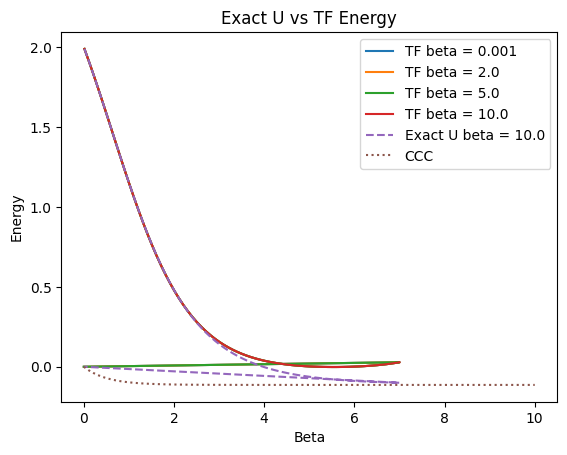

In [ ]:
for beta_idx in range(beta_array.shape[0]):
    plt.plot(TF_array[0, beta_idx][:y_trimmed.shape[0]][shift_array], TF_array[1, beta_idx][:y_trimmed.shape[0]][shift_array], label=f"TF beta = {beta_array[beta_idx]}")
    print(TF_array[1, beta_idx][:y_trimmed.shape[0]][-1])
plt.plot(TF_array[0, 0][:y_trimmed.shape[0]][shift_array], val_array[0, 0][:y_trimmed.shape[0]][shift_array], label=f"Exact U beta = {beta_array[beta_idx]}", linestyle="--")
plt.plot(time[time > shift], energy[time > shift], label=f"CCC", linestyle=":")
plt.title("Exact U vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

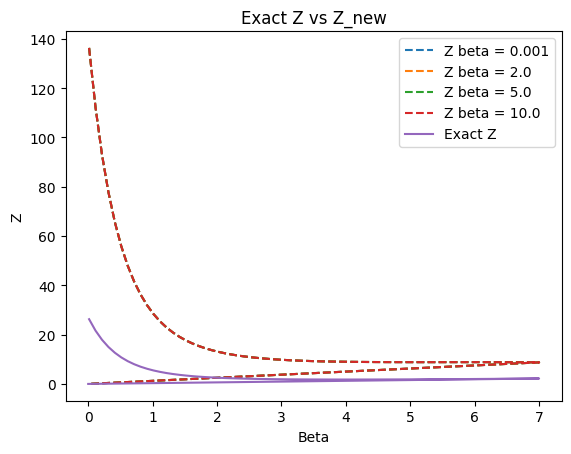

In [21]:
for beta_idx in range(beta_array.shape[0]):
    plt.plot(TF_array[0, 0][:y_trimmed.shape[0]][shift_array], val_array[2, 0][:y_trimmed.shape[0]][shift_array], label=f"Z beta = {beta_array[beta_idx]}", linestyle="--")
plt.plot(TF_array[0, 0][:y_trimmed.shape[0]][shift_array], val_array[1, 0][:y_trimmed.shape[0]][shift_array], label=f"Exact Z")
plt.title("Exact Z vs Z_new")
plt.xlabel("Beta")
plt.ylabel("Z")
plt.legend()
plt.show()

In [22]:
U, vec= bz.thermofield_change_of_basis(K)

I = np.eye(state)

K_prim = np.einsum('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

K_tilda = U.T @ K_prim @ U

V_tensor = V.reshape(state, state, state, state)

V_prim = np.einsum('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

V_grouped = V_prim.reshape(state**2, state**2, state**2, state**2)

V_tilda = np.einsum('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

[0.5773502692 0.5773502692 0.5773502692]
[1. 1.]


In [23]:
time_TF_old, energy_TD_TF_CCC_old, one_max_TD_TF_CC_old, two_max_TD_TF_CC_old = integration_scheme(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), periodic=periodic, t_init=0, t_final=10, nof_points=10000)

Single (0.6666666666666666+0j)
Double 0j
Double 0j
Single (0.6666666666666666+0j)
Double 0j
Single (0.6666666666666666+0j)
Single (0.6666549777440092+0j)
Double (-2.922230664375985e-07+0j)
Double 0j
Single (0.6666549777440092+0j)
Double (-2.922230664375985e-07+0j)
Single (0.6666549777440092+0j)
Single (0.6666491330492419+0j)
Double (-4.3834612750562826e-07+0j)
Double 0j
Single (0.6666491330463601+0j)
Double (-4.3834612750562826e-07+0j)
Single (0.6666491330492419+0j)
Single (0.6666403660654534+0j)
Double (-6.575278372462798e-07+0j)
Double 0j
Single (0.6666403660589688+0j)
Double (-6.5752783724628e-07+0j)
Single (0.6666403660654526+0j)
Single (0.6666040748792991+0j)
Double (-1.564867213432421e-06+0j)
Double 0j
Single (0.6666040748425743+0j)
Double (-1.5648672134324235e-06+0j)
Single (0.6666040748792886+0j)
Single (0.6665925884264013+0j)
Double (-1.8520575961146151e-06+0j)
Double 0j
Single (0.6665925883749619+0j)
Double (-1.852057596114619e-06+0j)
Single (0.6665925884263841+0j)
Single (0.

In [24]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF_old])

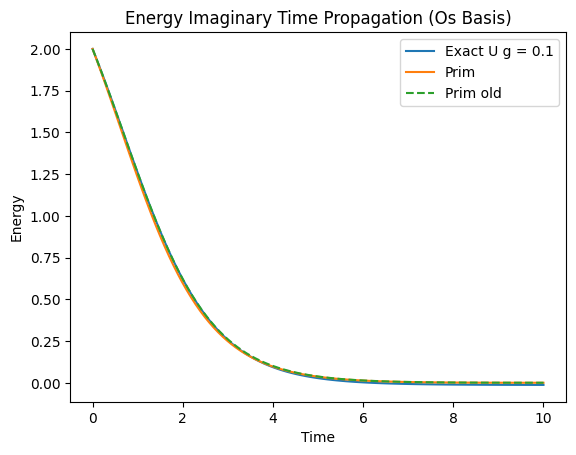

TF (0.0010291989438636281+0j)
Exact:  -0.012127832537906134


In [25]:
plt.plot(time_TF_old, ED_U_val, label=f"Exact U g = {g}")
plt.plot(time_TF, energy_TD_TF_CCC, label=f"Prim")
plt.plot(time_TF_old, energy_TD_TF_CCC_old, label=f"Prim old", linestyle="--")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TD_TF_CCC_old[-1])
print("Exact: ", ED_U_val[-1])

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


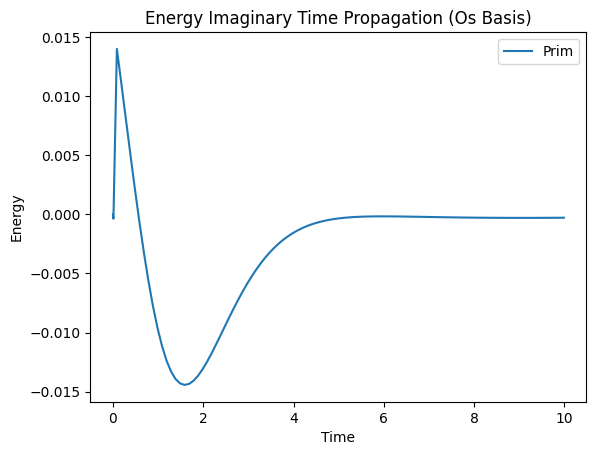

In [29]:
plt.plot(time_TF[:-1], energy_TD_TF_CCC[:-1] - energy_TD_TF_CCC_old, label=f"Prim")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [28]:
energy_TD_TF_CCC.shape

(104,)